# 동반 워크북 — KOFR OIS 계단함수로 금통위 인상확률 계산하기

**짝 문서.** [step_method_study.html](step_method_study.html) — 이 노트북의 셀 (a)~(h)는 본문의 코드 셀과 라벨·코드·출력이 글자까지 같습니다.

**검증 환경.** Python 3.14 · numpy 2.4 · matplotlib 3.10. 외부 데이터 파일이 필요 없습니다 — 입력(호가·회의 일정)은 전부 셀 안에 내장되어 있고, 출처는 각 셀에 적혀 있습니다.

**사용법.** 위에서 아래로 셀 단위로 실행합니다. 앞 셀이 정의한 함수를 뒤 셀이 쓰므로 순서를 건너뛰면 안 됩니다.

**한 줄 안내.** 2026-08-07의 KOFR OIS 호가 6개에서 출발해, 8·10·11월 금통위의 25bp 인상확률(50%·95%·36%)이 나오기까지의 모든 계산을 손으로 다시 돌려 봅니다. 마지막 셀은 다른 날짜(2026-07-15)의 호가로 처음부터 끝까지 혼자 풀어 보는 졸업시험입니다.

In [1]:
# 셋업 — 그림 스타일 + 공용 입력 데이터 (수정하지 않고 실행만 합니다)
import math
from datetime import date, timedelta
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

INK, MUTE, GRID = "#0A0A0A", "#6E6E6E", "#D6D6D6"
CADRED, CADBLUE, ORANGE = "#C53030", "#2D7EAA", "#ED8936"

plt.rcParams.update({
    "font.family": ["Malgun Gothic", "DejaVu Sans"],
    "axes.unicode_minus": False,
    "figure.dpi": 128, "savefig.dpi": 128, "savefig.bbox": "tight",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": INK, "axes.linewidth": 0.8,
    "axes.titlesize": 10.5, "axes.titlepad": 6,
    "axes.labelsize": 9, "axes.labelcolor": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "xtick.color": INK, "ytick.color": INK,
    "legend.fontsize": 8, "legend.frameon": False,
    "lines.linewidth": 1.4,
})

FIGDIR = Path("figs"); FIGDIR.mkdir(exist_ok=True)
def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIGDIR / name)
    return fig

# ── 입력 1 · 기준일 2026-08-07의 KOFR OIS 호가 (한국자금중개 MID, 인포맥스 수신)
ASOF = date(2026, 8, 7)
QUOTES = {"1주": 2.740, "1개월": 2.770, "2개월": 2.840, "3개월": 2.890,
          "6개월": 3.0725, "9개월": 3.205, "1년": 3.320}

# ── 입력 2 · 금통위 일정 (한국은행 공표. 2027년은 미공표 → 분기 가정 노드)
MEETINGS_2026 = [date(2026, 8, 27), date(2026, 10, 22), date(2026, 11, 26)]
NODES_2027 = [date(2027, 1, 15), date(2027, 4, 15), date(2027, 7, 15)]

# ── 입력 3 · 현재 기준금리 (2026-07-16 인상 후 2.75%)
BASE_RATE = 2.75

# ── 만기일 계산: "N개월"은 달력 월 가산 (8/7 + 3개월 = 11/7 → 92일)
def add_months(d, months):
    month = d.month - 1 + months
    year = d.year + month // 12
    month = month % 12 + 1
    day = min(d.day, [31, 29 if year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)
                      else 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31][month - 1])
    return date(year, month, day)

def tenor_days(asof, tenor):
    if tenor == "1주":
        return 7
    n = {"1개월": 1, "2개월": 2, "3개월": 3, "6개월": 6, "9개월": 9, "1년": 12}[tenor]
    return (add_months(asof, n) - asof).days

FIT_TENORS = ["1개월", "2개월", "3개월", "6개월", "9개월", "1년"]
DAYS = {t: tenor_days(ASOF, t) for t in FIT_TENORS}
print("기준일:", ASOF, "· 기준금리:", BASE_RATE, "%")
print("만기 일수:", DAYS)
print("회의 노드:", [m.isoformat() for m in MEETINGS_2026 + NODES_2027])

기준일: 2026-08-07 · 기준금리: 2.75 %
만기 일수: {'1개월': 31, '2개월': 61, '3개월': 92, '6개월': 184, '9개월': 273, '1년': 365}
회의 노드: ['2026-08-27', '2026-10-22', '2026-11-26', '2027-01-15', '2027-04-15', '2027-07-15']


## 셀 (a) — 변동다리의 복리 곱과 연율화 관행 검증

**이 셀이 하는 일.** OIS 변동다리의 원리금 배율(하루짜리 금리를 매일 복리로 굴린 곱)을 계산하는 함수를 만들고, 고정금리 호가로 바꾸는 연율화 관행 두 가지 — KRX 명세의 **Act/365 단리**와, 구판 모형이 잘못 썼던 **유효연율** — 를 나란히 놓고 비교합니다.

**판정 기준은 시장이 줍니다.** 1주 구간에는 금통위가 없으므로, 하루짜리 금리가 1주 내내 시작 수준 그대로라고 두면 모형이 1주 호가(2.740%)를 그대로 재현해야 합니다. 단리 관행은 재현하고, 유효연율 관행은 3.8bp 어긋납니다 — 관행을 하나 고를 때마다 이 검증을 먼저 돌려야 하는 이유입니다.

1주 시장 호가       : 2.7400%
단리 연율화 (KRX)   : 2.7406%  <- 재현
유효연율 (구판 오류): 2.7778%  <- 3.8bp 초과

동결 경로(전 구간 2.740%)의 만기별 고정금리:
만기    일수   단리(KRX)   유효연율
1개월     31   2.7431%    2.7778%
2개월     61   2.7462%    2.7778%
3개월     92   2.7494%    2.7778%
6개월    184   2.7589%    2.7778%
9개월    273   2.7682%    2.7778%
1년     365   2.7778%    2.7778%


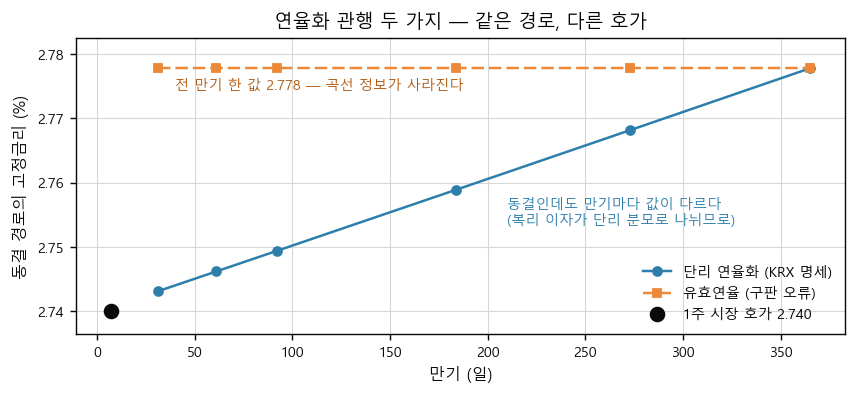

In [2]:
# 셀 (a) · 연율화 두 관행 — 1주 호가 재현 검증
# 경로가 일정 구간별로 (일수, 금리%) 로 주어질 때 복리 곱의 로그를 계산
def log_growth(segments):
    return sum(n * math.log(1 + r / 100 / 365) for n, r in segments)

def k_simple(segments, days):
    # KRX KOFR OIS 명세: K = (365/D) * [곱 - 1]  (Act/365 단리 연율화)
    return (math.exp(log_growth(segments)) - 1) * 365 / days * 100

def k_effective(segments, days):
    # 구판의 잘못된 관행: K = 곱^(365/D) - 1  (유효연율)
    return (math.exp(log_growth(segments) * 365 / days) - 1) * 100

# 검증 1 — 1주 동결 경로가 1주 호가를 재현하는가
r0 = QUOTES["1주"]
flat_1w = [(7, r0)]
print(f"1주 시장 호가       : {QUOTES['1주']:.4f}%")
print(f"단리 연율화 (KRX)   : {k_simple(flat_1w, 7):.4f}%  <- 재현")
print(f"유효연율 (구판 오류): {k_effective(flat_1w, 7):.4f}%  <- 3.8bp 초과")

# 검증 2 — 동결 경로의 만기별 고정금리 (두 관행)
print("\n동결 경로(전 구간 " + f"{r0:.3f}%)의 만기별 고정금리:")
print("만기    일수   단리(KRX)   유효연율")
hold_simple, hold_eff = {}, {}
for t in FIT_TENORS:
    d_ = DAYS[t]
    hold_simple[t] = k_simple([(d_, r0)], d_)
    hold_eff[t] = k_effective([(d_, r0)], d_)
    print(f"{t:<5s} {d_:>4d}   {hold_simple[t]:.4f}%    {hold_eff[t]:.4f}%")

fig, ax = plt.subplots(figsize=(6.8, 3.2))
xs = [DAYS[t] for t in FIT_TENORS]
ax.plot(xs, [hold_simple[t] for t in FIT_TENORS], color=CADBLUE, marker="o",
        ms=5, label="단리 연율화 (KRX 명세)")
ax.plot(xs, [hold_eff[t] for t in FIT_TENORS], color=ORANGE, marker="s",
        ms=5, ls=(0, (5, 2)), label="유효연율 (구판 오류)")
ax.scatter([7], [QUOTES["1주"]], s=60, color=INK, zorder=5, label="1주 시장 호가 2.740")
ax.annotate("동결인데도 만기마다 값이 다르다\n(복리 이자가 단리 분모로 나뉘므로)",
            xy=(210, 2.7535), fontsize=8, color=CADBLUE)
ax.annotate("전 만기 한 값 2.778 — 곡선 정보가 사라진다",
            xy=(40, 2.7745), fontsize=8, color="#B05A10")
ax.set_ylim(2.7365, 2.7825)
ax.set_xlabel("만기 (일)")
ax.set_ylabel("동결 경로의 고정금리 (%)")
ax.set_title("연율화 관행 두 가지 — 같은 경로, 다른 호가")
ax.legend(loc="lower right")
save(fig, "03-annualization-conventions.png")
plt.show()

**결과 읽기.** 단리 관행은 1주 호가를 2.7403%로 재현합니다(시장 2.740%, 오차 0.03bp). 유효연율은 2.7779% — 3.8bp나 벗어납니다. 그리고 동결 경로의 만기별 값을 보면 두 관행의 성격 차이가 드러납니다. 단리는 2.743%에서 2.778%로 만기를 따라 올라가고(복리로 불어난 이자를 단리 분모로 나누므로), 유효연율은 전 만기가 2.7779% 한 값입니다.

**현실 매핑.** 구판 모형은 유효연율을 썼습니다. 그러면 "동결이면 곡선이 평평해야 한다"가 되어, 실제 곡선의 완만한 우상향까지 전부 인상 기대로 읽혀야 할 몫이 줄어듭니다 — 8월 확률이 30%로 눌려 있던 원인입니다. 관행을 단리로 바로잡자 적합 오차(RMSE)가 1.5bp에서 0.8bp로 반감했습니다. 시장 호가 자체가 어느 관행이 맞는지 심판해 준 셈입니다.

## 셀 (b) — 계단 경로의 가격 함수와 2개월 호가 손계산

**이 셀이 하는 일.** "하루짜리 금리는 금통위 날에만 Δ만큼 점프한다"는 계단 경로를 코드로 만들고(`model_rate`), 이를 2개월 호가 하나에 적용해 8월 인상확률을 손으로 읽어 냅니다.

**모형 식.** 기준일로부터 $s$일 뒤의 하루짜리 금리를

$$r(s) = r_0 + \sum_k \Delta_k \cdot \mathbf{1}\{s \ge m_k\}$$

로 둡니다 — $m_k$는 $k$번째 금통위까지의 일수, $\Delta_k$는 그 회의의 점프 폭, $r_0$는 경로의 시작 수준(1주 호가로 캘리브레이션)입니다. 만기 $D$일짜리 OIS의 고정금리는 이 경로를 구간별로 복리로 굴려 셀 (a)의 단리 관행으로 연율화한 값입니다.

2개월 만기 61일 · 회의까지 20일 · 회의 뒤 41일
동결 경로의 2개월 고정금리 : 2.7462%
인상 경로의 2개월 고정금리 : 2.9150%  (동결 대비 +16.9bp)
시장 호가                  : 2.8400%  (동결 대비 +9.4bp)
=> 2개월 호가 하나로 읽은 8월 인상확률 P = 55.6%

1개월(31일·회의 뒤 11일)로 같은 계산: 동결 2.7431 · 인상 2.8320 · 시장 2.7700 => P = 30.3%


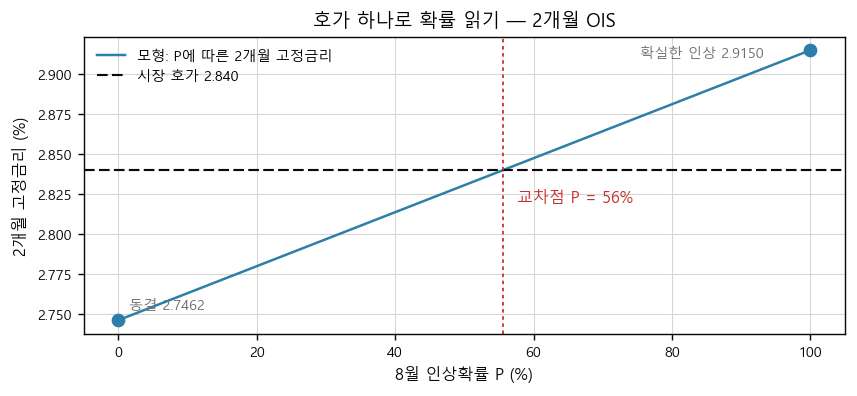

In [3]:
# 셀 (b) · model_rate — 계단 경로를 넣으면 고정금리가 나오는 함수
def model_rate(asof, days, r0, nodes, deltas):
    # 경로를 (일수, 금리) 구간 목록으로 자른 뒤 셀 (a)의 단리 연율화 적용
    segments, prev, cur = [], 0, r0
    for b, dlt in sorted(((n - asof).days, dl) for n, dl in zip(nodes, deltas)):
        if b >= days:
            break                     # 만기 밖의 회의는 이 호가와 무관
        if b > prev:
            segments.append((b - prev, cur))
            prev = b
        cur += dlt                    # 회의를 지나며 금리가 점프
    segments.append((days - prev, cur))
    return k_simple(segments, days)

# ── 2개월 호가(61일) 손계산: 회의(8/27)는 20일째, 그 뒤가 41일
r0 = QUOTES["1주"]                    # 경로 시작 수준 = 1주 호가 2.740
nodes_1 = [MEETINGS_2026[0]]          # 8/27 하나만 고려
D2 = DAYS["2개월"]
m_aug = (MEETINGS_2026[0] - ASOF).days
print(f"2개월 만기 {D2}일 · 회의까지 {m_aug}일 · 회의 뒤 {D2 - m_aug}일")

hold = model_rate(ASOF, D2, r0, nodes_1, np.array([0.0]))     # 동결 경로
full = model_rate(ASOF, D2, r0, nodes_1, np.array([0.25]))    # 25bp 인상 경로
mkt = QUOTES["2개월"]
p_2m = (mkt - hold) / (full - hold)
print(f"동결 경로의 2개월 고정금리 : {hold:.4f}%")
print(f"인상 경로의 2개월 고정금리 : {full:.4f}%  (동결 대비 +{(full-hold)*100:.1f}bp)")
print(f"시장 호가                  : {mkt:.4f}%  (동결 대비 +{(mkt-hold)*100:.1f}bp)")
print(f"=> 2개월 호가 하나로 읽은 8월 인상확률 P = {p_2m:.1%}")

# 같은 계산을 1개월 호가로
D1 = DAYS["1개월"]
hold1 = model_rate(ASOF, D1, r0, nodes_1, np.array([0.0]))
full1 = model_rate(ASOF, D1, r0, nodes_1, np.array([0.25]))
p_1m = (QUOTES["1개월"] - hold1) / (full1 - hold1)
print(f"\n1개월(31일·회의 뒤 11일)로 같은 계산: 동결 {hold1:.4f} · 인상 {full1:.4f}"
      f" · 시장 {QUOTES['1개월']:.4f} => P = {p_1m:.1%}")

fig, ax = plt.subplots(figsize=(6.8, 3.2))
ps = np.linspace(0, 1, 101)
line = [model_rate(ASOF, D2, r0, nodes_1, np.array([0.25 * p])) for p in ps]
ax.plot(ps * 100, line, color=CADBLUE, label="모형: P에 따른 2개월 고정금리")
ax.axhline(mkt, color=INK, lw=1.2, ls=(0, (5, 2)), label=f"시장 호가 {mkt:.3f}")
ax.axvline(p_2m * 100, color=CADRED, lw=1.0, ls=(0, (2, 2)))
ax.annotate(f"교차점 P = {p_2m:.0%}", xy=(p_2m * 100, mkt),
            xytext=(8, -18), textcoords="offset points", color=CADRED, fontsize=9)
ax.scatter([0, 100], [hold, full], s=45, color=CADBLUE, zorder=5)
ax.annotate(f"동결 {hold:.4f}", xy=(0, hold), xytext=(6, 6),
            textcoords="offset points", fontsize=8, color=MUTE)
ax.annotate(f"확실한 인상 {full:.4f}", xy=(100, full), xytext=(-96, -4),
            textcoords="offset points", fontsize=8, color=MUTE)
ax.set_xlabel("8월 인상확률 P (%)")
ax.set_ylabel("2개월 고정금리 (%)")
ax.set_title("호가 하나로 확률 읽기 — 2개월 OIS")
ax.legend(loc="upper left")
save(fig, "05-two-month-readout.png")
plt.show()

**결과 읽기.** 동결이면 2개월 고정금리가 2.7462%, 인상이 확실하면 2.9142% — 폭 16.8bp가 이 호가가 8월 회의에 대해 가질 수 있는 전 구간입니다. 시장은 2.840%, 동결 대비 +9.4bp를 매겼으니 P = 9.4/16.8 ≈ **56%**입니다. 1개월 호가로 같은 계산을 하면 **30%**가 나옵니다.

**두 값이 다르다는 것 자체가 다음 단계의 예고편입니다.** 호가마다 매수·매도 호가 사이 어중간한 위치, 유동성, 수급이 조금씩 다르므로 한 호가짜리 독해는 그 호가의 잡음을 그대로 물려받습니다. 그래서 실제 모형은 6개 호가를 **한꺼번에** 적합해 잡음을 상쇄시킵니다 — 그 결과가 50%입니다(셀 e·f). 또 하나, 확률 P가 x축, 고정금리가 y축인 위 그림에서 관계가 거의 직선인 것도 확인해 두세요. 점프 폭에 대해 가격이 사실상 선형이라는 사실은 셀 (e)의 가우스-뉴턴 첫 스텝이 답의 대부분을 만드는 이유가 됩니다.

## 셀 (c) — 어느 호가가 어느 회의를 보는가: 커버리지와 민감도

**이 셀이 하는 일.** 만기 6개 × 회의 노드 6개의 민감도 행렬을 계산합니다. 성분 하나하나는 "그 회의에서 25bp를 올리면 그 만기 호가가 몇 bp 움직이는가"를 25bp로 나눈 비율 — 근사적으로 **만기 안에서 회의 뒤에 남는 날수의 비중**입니다.

$$\frac{\partial K_D}{\partial \Delta_k} \approx \frac{D - m_k}{D} \quad (m_k < D)$$

이 행렬이 뒤에 나올 모든 이야기의 지도입니다 — 어떤 회의가 잘 식별되고(열이 진하다), 어떤 회의가 희미하게만 보이는지(열이 옅다)를 여기서 다 읽을 수 있습니다.

민감도 행렬 (행=만기, 열=회의):
        26/08/27  26/10/22  26/11/26  27/01/15  27/04/15  27/07/15
1개월       0.355     0.000     0.000     0.000     0.000     0.000
2개월       0.672     0.000     0.000     0.000     0.000     0.000
3개월       0.783     0.174     0.000     0.000     0.000     0.000
6개월       0.891     0.587     0.397     0.125     0.000     0.000
9개월       0.927     0.722     0.593     0.410     0.081     0.000
1년        0.945     0.792     0.696     0.559     0.312     0.063

예: 3개월(92일) 호가의 10/22 민감도 = (92-76)/92 = 0.174
=> 10월 인상 25bp는 3개월 호가를 약 4.3bp만 움직인다


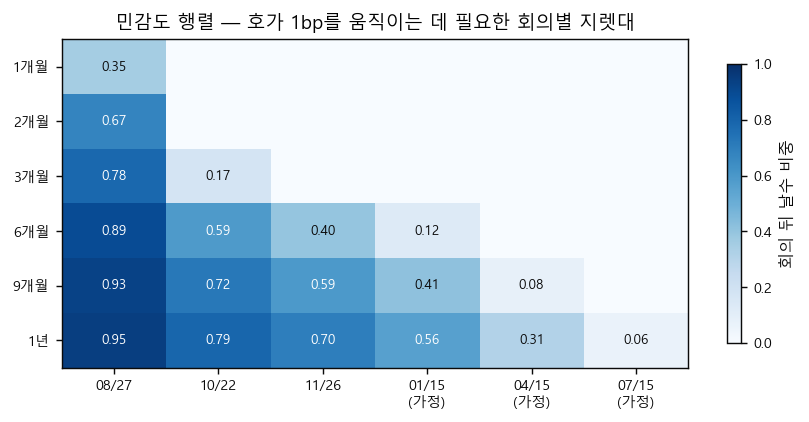

In [4]:
# 셀 (c) · 민감도 행렬 — 성분 = 만기 내 회의-이후 날수 비중
ALL_NODES = MEETINGS_2026 + NODES_2027
J_frac = np.zeros((len(FIT_TENORS), len(ALL_NODES)))
for i, t in enumerate(FIT_TENORS):
    for k, n in enumerate(ALL_NODES):
        b = (n - ASOF).days
        if b < DAYS[t]:
            J_frac[i, k] = (DAYS[t] - b) / DAYS[t]

print("민감도 행렬 (행=만기, 열=회의):")
hdr = "        " + "  ".join(n.strftime("%y/%m/%d") for n in ALL_NODES)
print(hdr)
for i, t in enumerate(FIT_TENORS):
    print(f"{t:<6s} " + "  ".join(f"{v:8.3f}" for v in J_frac[i]))

d3, b_oct = DAYS["3개월"], (MEETINGS_2026[1] - ASOF).days
print(f"\n예: 3개월({d3}일) 호가의 10/22 민감도 = ({d3}-{b_oct})/{d3}"
      f" = {(d3-b_oct)/d3:.3f}")
print("=> 10월 인상 25bp는 3개월 호가를 약 " f"{25*(d3-b_oct)/d3:.1f}bp만 움직인다")

fig, ax = plt.subplots(figsize=(6.8, 3.4))
im = ax.imshow(J_frac, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(ALL_NODES)),
              [n.strftime("%m/%d") + ("\n(가정)" if n.year == 2027 else "")
               for n in ALL_NODES], fontsize=8)
ax.set_yticks(range(len(FIT_TENORS)), FIT_TENORS, fontsize=8)
for i in range(len(FIT_TENORS)):
    for k in range(len(ALL_NODES)):
        v = J_frac[i, k]
        if v > 0:
            ax.text(k, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                    color="white" if v > 0.55 else INK)
ax.set_title("민감도 행렬 — 호가 1bp를 움직이는 데 필요한 회의별 지렛대")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.85, label="회의 뒤 날수 비중")
save(fig, "06-coverage-jacobian.png")
plt.show()

**결과 읽기.** 1·2개월 행은 8/27 열만 값이 있습니다 — 8월 회의를 단독으로 식별하는 것은 이 두 호가뿐입니다. 3개월 행부터 10/22 열이 켜지는데 값이 0.174에 불과합니다. 10월에 25bp를 올려도 3개월 호가는 4.3bp밖에 안 움직인다는 뜻입니다. 이 "옅은 열"이 다음 셀의 주인공입니다 — 민감도가 작은 방향은 거꾸로 풀 때 잡음이 크게 증폭됩니다.

**현실 매핑.** 미국 FedWatch가 페드펀드 **선물**(회의 구간별 상품)을 쓰는 것과 달리 한국 KOFR OIS는 만기 몇 개짜리 **누적** 상품만 있으므로, 회의별 분해는 언제나 이 행렬을 거꾸로 푸는 문제가 됩니다. 열이 진한 앞 회의는 믿을 만하게, 열이 옅은 뒷 회의는 조심스럽게 읽어야 하는 구조적 이유가 이 행렬에 있습니다.

## 셀 (d) — 그냥 풀면 무슨 일이 나는가: 특이성과 잡음 증폭

**이 셀이 하는 일.** 규칙화(가중·평활·수축) 없이 "호가 6개 = 미지수 6개니까 연립을 정확히 풀면 되겠지"를 실제로 시도합니다. 결과는 두 단계로 무너집니다 — ① 민감도 행렬의 계수(rank)가 5라서 **정확해가 아예 유일하지 않고**, ② 그나마 얌전한 최소노름 해를 골라도 호가 **1틱(0.25bp)** 의 잡음이 점프 추정치를 몇 bp씩 흔듭니다.

**왜 이 실험이 필요한가.** 셀 (c)의 행렬을 다시 보면 1개월과 2개월 행은 8/27 열 하나만 값이 있습니다 — 방정식 두 개가 같은 미지수 하나를 두 번 재고 있는 셈이라, 독립인 방정식은 사실상 5개뿐입니다. 게다가 뒷 회의의 민감도는 0.1~0.3 수준이라, 민감도 0.17짜리 방향에서는 호가 1bp의 잡음이 점프 추정치를 1/0.17 ≈ 6bp 움직일 수 있습니다 — 확률로는 25bp 격자의 24%p입니다. 이 두 가지를 숫자로 직접 확인합니다.

민감도 행렬의 특이값: 2.552 0.762 0.248 0.093 0.057 0.000
=> 여섯째 특이값이 0 — 계수(rank)는 5. 6x6 '정확해'는 유일하지 않다.
   (np.linalg.solve로 그냥 풀면 특이행렬이라 해가 폭주한다)
유효 조건수 (첫째/다섯째 특이값 비): 45  — 최악 방향으로는 잡음이 이 배율로 증폭될 수 있다

최소노름 해 (bp): +12.5 +23.9 +8.9 +17.3 +18.2 +4.3

+1틱 섭동별 해의 변화 (bp):
섭동 만기   08/27  10/22  11/26  01/15  04/15  07/15
1개월         +0.15     -0.69     +0.74     -0.20     -0.02     +0.05
2개월         +0.29     -1.30     +1.40     -0.37     -0.03     +0.09
3개월         +0.00     +1.43     -2.42     +0.98     +0.06     -0.19
6개월         +0.00     -0.00     +1.20     -1.84     +0.53     +0.44
9개월         +0.00     -0.00     -0.54     +1.71     -1.70     -0.79
1년          +0.00     -0.00     +0.13     -0.41     +1.13     +0.43


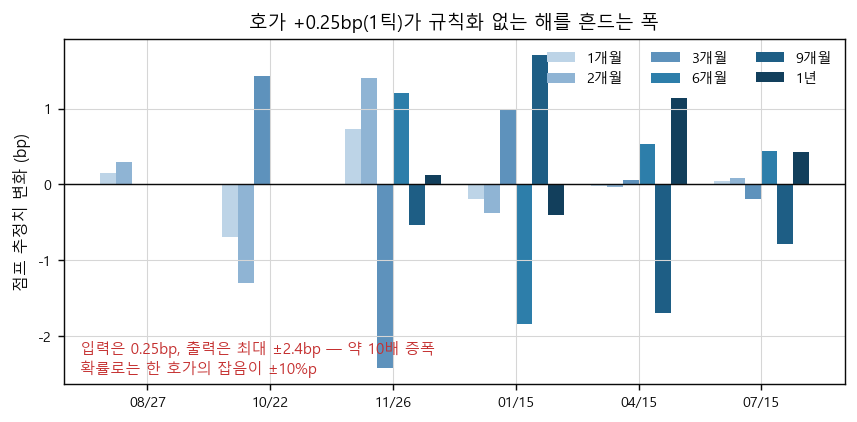

In [5]:
# 셀 (d) · 특이성 확인 + 최소노름 해의 1틱 섭동 실험 (규칙화 전부 끄고)
def solve_naive(quotes_dict):
    # 규칙화 없는 최소제곱 (뉴턴 반복 + lstsq = 최소노름 해)
    yv = np.array([quotes_dict[t] for t in FIT_TENORS])
    days_l = [DAYS[t] for t in FIT_TENORS]
    deltas, eps = np.zeros(len(ALL_NODES)), 1e-4
    for _ in range(8):
        f0 = np.array([model_rate(ASOF, d_, r0, ALL_NODES, deltas) for d_ in days_l])
        J = np.zeros((len(days_l), len(ALL_NODES)))
        for k in range(len(ALL_NODES)):
            dd = deltas.copy(); dd[k] += eps
            J[:, k] = (np.array([model_rate(ASOF, d_, r0, ALL_NODES, dd)
                                 for d_ in days_l]) - f0) / eps
        step, *_ = np.linalg.lstsq(J, yv - f0, rcond=None)
        deltas = deltas + step
        if np.max(np.abs(step)) < 1e-9:
            break
    return deltas, J

base_dl, J = solve_naive(QUOTES)
sv = np.linalg.svd(J, compute_uv=False)
print("민감도 행렬의 특이값:", " ".join(f"{s:.3f}" for s in sv))
print("=> 여섯째 특이값이 0 — 계수(rank)는 5. 6x6 '정확해'는 유일하지 않다.")
print("   (np.linalg.solve로 그냥 풀면 특이행렬이라 해가 폭주한다)")
print(f"유효 조건수 (첫째/다섯째 특이값 비): {sv[0]/sv[4]:.0f}"
      "  — 최악 방향으로는 잡음이 이 배율로 증폭될 수 있다")
print("\n최소노름 해 (bp):",
      " ".join(f"{d_*100:+.1f}" for d_ in base_dl))

# 만기 하나씩 +1틱(0.25bp) 올려 보고 해가 얼마나 움직이는지
TICK = 0.0025
print("\n+1틱 섭동별 해의 변화 (bp):")
print("섭동 만기   " + "  ".join(n.strftime("%m/%d") for n in ALL_NODES))
swings = {}
for t in FIT_TENORS:
    q2 = dict(QUOTES); q2[t] = q2[t] + TICK
    dl2, _ = solve_naive(q2)
    swings[t] = (dl2 - base_dl) * 100
    print(f"{t:<8s} " + "  ".join(f"{v:+8.2f}" for v in swings[t]))

fig, ax = plt.subplots(figsize=(6.8, 3.4))
width = 0.13
xs = np.arange(len(ALL_NODES))
shades = ["#BDD4E7", "#8FB4D4", "#5E92BC", "#2D7EAA", "#1E5E85", "#123F5C"]
for j, t in enumerate(FIT_TENORS):
    ax.bar(xs + (j - 2.5) * width, swings[t], width, color=shades[j], label=t)
ax.axhline(0, color=INK, lw=0.8)
ax.set_xticks(xs, [n.strftime("%m/%d") for n in ALL_NODES], fontsize=8)
ax.set_ylabel("점프 추정치 변화 (bp)")
ax.set_title("호가 +0.25bp(1틱)가 규칙화 없는 해를 흔드는 폭")
ax.annotate("입력은 0.25bp, 출력은 최대 ±2.4bp — 약 10배 증폭\n"
            "확률로는 한 호가의 잡음이 ±10%p", xy=(0.02, 0.03),
            xycoords="axes fraction", fontsize=8.5, color=CADRED)
ax.legend(ncols=3, loc="upper right")
save(fig, "07-noise-amplification.png")
plt.show()

**결과 읽기.** 특이값이 말부터 해 줍니다. 여섯째 특이값이 0이라는 것은 — 여섯 미지수 가운데 한 방향(사실상 2027-07 가정 노드)은 어떤 호가도 구분해 주지 못해서, 그 방향으로는 해를 아무렇게나 옮겨도 호가가 안 바뀐다는 뜻입니다. 그래서 "정확해"는 하나가 아니라 무한히 많고, `np.linalg.solve`는 아예 폭주합니다. 방정식 6개를 세는 것만으로는 부족하고 **커버리지의 구조**(셀 c)까지 봐야 하는 이유입니다.

섭동 표에서는 증폭이 보입니다. 입력은 0.25bp인데 뒷 회의 점프 추정치는 1~2.4bp씩 움직입니다 — 약 10배 증폭이고, 여러 호가가 동시에 흔들리는 실제 장에서는 이 효과가 겹칩니다. 유효 조건수(약 45)가 그 상한을 요약합니다. 섭동의 부호 패턴도 봐 두세요 — 이웃한 회의들이 **반대 방향으로** 움직입니다(예: 3개월 +1틱에 10/22는 +1.4bp, 11/26은 −2.4bp). 합(누적)은 지키면서 배분만 서로 뺏고 빼앗기는 것이 이 문제 잡음의 전형적 모양입니다.

**현실 매핑.** 실제로 규칙화를 붙인 운영 모형조차 8월 배분 확률이 한 달 사이 100%와 26%를 오갑니다(본문 도표 12) — 규칙화 없는 판은 이보다 험합니다. "누적(연말 내재 금리)은 잘 식별되고 회의별 배분은 잡음이 크다"는 이 방법론의 제1 규율이 여기서 나옵니다.

## 셀 (e) — 규칙화 붙이기: 가중 + 평활 + 수축, 그리고 그것이 작동하는 실제 방식

**이 셀이 하는 일.** 실전 엔진 `fit_deltas`를 완성하고, 벌점이 답을 실제로 어떻게 바꾸는지를 세 가지 변형의 대조로 확인한 뒤, λ를 훑어 채택값 2×10⁻³의 자리를 봅니다. 셀 (d)의 조건에 세 가지가 더해집니다.

1. **가중 (W).** 만기별 가중 1.0/1.0/1.0/0.9/0.8/0.7 — 뒤로 갈수록 기간프리미엄과 2027 가정 노드의 오염이 커지므로 뒷 만기의 발언권을 낮춥니다.
2. **평활 (λDᵀD).** 이웃 회의 점프의 차이에 벌점 — 셀 (d)에서 본 "이웃끼리 반대로 널뛰는" 잡음 방향을 정확히 겨냥한 처방입니다.
3. **수축 (T).** 각 점프를 0으로 살짝 당기는 벌점 — 2026 회의는 아주 약하게(2×10⁻⁴), 일정도 안 나온 2027 가정 노드는 5배 세게(10⁻³). 셀 (d)에서 본 "어떤 호가도 못 보는 방향"이 남았을 때 해가 폭주하지 않고 0 근처에 머물게 하는 안전핀입니다.

**설계 의도의 목적함수.**

$$\min_{\Delta}\; (y - K(\Delta))^\top W (y - K(\Delta)) + \lambda \|D\Delta\|^2 + \Delta^\top T \Delta$$

**구현의 실제 — 여기가 미묘한 지점입니다.** 운영 코드는 이 벌점을 가우스-뉴턴 갱신식의 **곡률(정규방정식 좌변)에만** 넣습니다.

$$\Delta \leftarrow \Delta + (J^\top W J + \lambda D^\top D + T)^{-1} J^\top W (y - K(\Delta))$$

이 갱신을 8회 반복합니다. 목적함수를 곧이곧대로 최소화한 "정확 벌점 최적해"와는 답이 다릅니다 — 어느 쪽이 어떻게 다르고 왜 운영은 이쪽을 택했는지, 코드로 직접 셋을 나란히 놓고 확인합니다.

운영 적합 (벌점=좌변만, 8회, λ=2e-3):
  2026-08-27: +12.54bp -> P = 50.2%
  2026-10-22: +23.77bp -> P = 95.1%
  2026-11-26:  +9.00bp -> P = 36.0%
  2027-01-15 (2027 가정): +17.81bp -> P = 71.2%
  2027-04-15 (2027 가정): +16.13bp -> P = 64.5%
  2027-07-15 (2027 가정): +11.15bp -> P = 44.6%
  가중 RMSE 0.81bp · 스텝 크기: 2e-01 2e-02 1e-02 8e-03 5e-03 3e-03 2e-03 2e-03

                       8/27        10/22       11/26     가중RMSE
운영 구현(8회)    +12.5bp/ 50%  +23.8bp/ 95%   +9.0bp/ 36%   0.81bp
운영 구현(200회)  +12.5bp/ 50%  +23.9bp/ 96%   +8.6bp/ 35%   0.81bp
정확 벌점 최적해  +12.9bp/ 52%  +20.2bp/ 81%  +14.5bp/ 58%   0.84bp



λ 민감도 (8/27 확률): λ=0.001: 50% · λ=0.002: 50% · λ=0.004: 50%
λ 민감도 (11/26 확률): λ=0.001: 35% · λ=0.002: 36% · λ=0.004: 40%


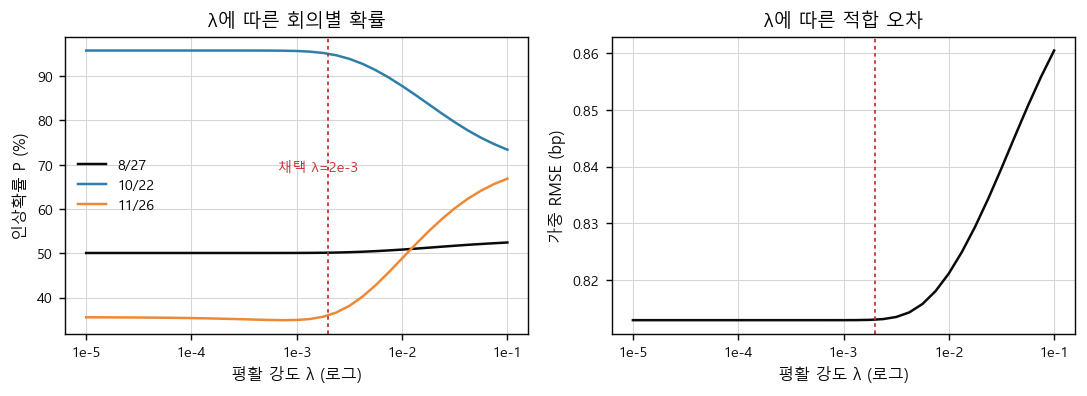

In [6]:
# 셀 (e) · fit_deltas — 실전 엔진 (기본 인자에서 m1_step_function.py 와 동일)
TENOR_W = {"1개월": 1.0, "2개월": 1.0, "3개월": 1.0, "6개월": 0.9,
           "9개월": 0.8, "1년": 0.7}
LAMBDA_SMOOTH, SHRINK_2026, SHRINK_2027 = 2.0e-3, 2.0e-4, 1.0e-3

def fit_deltas(asof, obs_days, obs_vals, weights, nodes, is_ph, r0,
               smooth=LAMBDA_SMOOTH, shrink26=SHRINK_2026, shrink27=SHRINK_2027,
               iters=8, exact_rhs=False):
    # exact_rhs=False (운영): 벌점은 스텝의 곡률(좌변)에만 — 감쇠 가우스-뉴턴
    # exact_rhs=True  (비교용): 벌점을 우변에도 — 목적함수의 정확 최적해로 수렴
    K = len(nodes)
    D = np.zeros((max(K - 1, 1), K))          # 이웃 차분 행렬
    for i in range(K - 1):
        D[i, i], D[i, i + 1] = -1.0, 1.0
    R = smooth * D.T @ D + np.diag(np.where(is_ph, shrink27, shrink26))
    W = np.diag(weights)

    def price_vec(dl):
        return np.array([model_rate(asof, d_, r0, nodes, dl) for d_ in obs_days])

    deltas, eps = np.zeros(K), 1e-4
    steps = []
    for _ in range(iters):                     # 가우스-뉴턴 반복
        f0 = price_vec(deltas)
        J = np.zeros((len(obs_days), K))
        for k in range(K):
            dd = deltas.copy(); dd[k] += eps
            J[:, k] = (price_vec(dd) - f0) / eps
        lhs = J.T @ W @ J + R
        rhs = J.T @ W @ (obs_vals - f0)
        if exact_rhs:
            rhs = rhs - R @ deltas
        step = np.linalg.solve(lhs, rhs)
        deltas = deltas + step
        steps.append(np.max(np.abs(step)))
        if steps[-1] < 1e-6:
            break
    fitted = price_vec(deltas)
    rmse = float(np.sqrt(np.mean(((obs_vals - fitted) * weights) ** 2)))
    return deltas, rmse, fitted, steps

IS_PH = np.array([n.year == 2027 for n in ALL_NODES])
y = np.array([QUOTES[t] for t in FIT_TENORS])
w = np.array([TENOR_W[t] for t in FIT_TENORS])
days_l = [DAYS[t] for t in FIT_TENORS]

dl, rmse, fitted, steps = fit_deltas(ASOF, days_l, y, w, ALL_NODES, IS_PH, r0)
print("운영 적합 (벌점=좌변만, 8회, λ=2e-3):")
for n, d_ in zip(ALL_NODES, dl):
    tag = " (2027 가정)" if n.year == 2027 else ""
    print(f"  {n}{tag}: {d_*100:+6.2f}bp -> P = {min(max(d_/0.25,0),1):.1%}")
print(f"  가중 RMSE {rmse*100:.2f}bp · 스텝 크기: "
      + " ".join(f"{s:.0e}" for s in steps))

# ── 세 변형 대조: 운영(8회) / 운영을 200회까지 / 정확 벌점 최적해
dl200, rm200, _, _ = fit_deltas(ASOF, days_l, y, w, ALL_NODES, IS_PH, r0, iters=200)
dlex, rmex, _, _ = fit_deltas(ASOF, days_l, y, w, ALL_NODES, IS_PH, r0,
                              iters=200, exact_rhs=True)
print("\n                       8/27        10/22       11/26     가중RMSE")
for lab, d_, rm_ in [("운영 구현(8회)   ", dl, rmse),
                     ("운영 구현(200회) ", dl200, rm200),
                     ("정확 벌점 최적해 ", dlex, rmex)]:
    p3 = [f"{v*100:+5.1f}bp/{min(max(v/0.25,0),1):4.0%}" for v in d_[:3]]
    print(f"{lab} " + "  ".join(p3) + f"   {rm_*100:.2f}bp")

# ── λ 훑기: 배분(회의별 확률)과 적합 오차의 맞교환 (운영 방식 기준)
lams = np.logspace(-5, -1, 33)
probs, rmses = [], []
for lam in lams:
    d2, r2, _, _ = fit_deltas(ASOF, days_l, y, w, ALL_NODES, IS_PH, r0, smooth=lam)
    probs.append([min(max(v / 0.25, 0), 1) for v in d2[:3]])
    rmses.append(r2 * 100)
probs = np.array(probs)
print("\nλ 민감도 (8/27 확률): "
      + " · ".join(f"λ={lam_:g}: {np.interp(np.log10(lam_), np.log10(lams), probs[:,0])*100:.0f}%"
                   for lam_ in [1e-3, 2e-3, 4e-3]))
print("λ 민감도 (11/26 확률): "
      + " · ".join(f"λ={lam_:g}: {np.interp(np.log10(lam_), np.log10(lams), probs[:,2])*100:.0f}%"
                   for lam_ in [1e-3, 2e-3, 4e-3]))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(8.6, 3.2))
for j, (lab, c_) in enumerate([("8/27", INK), ("10/22", CADBLUE), ("11/26", ORANGE)]):
    axL.plot(lams, probs[:, j] * 100, color=c_, label=lab)
axL.axvline(LAMBDA_SMOOTH, color=CADRED, lw=1.0, ls=(0, (2, 2)))
axL.annotate("채택 λ=2e-3", xy=(0.46, 0.55), xycoords="axes fraction",
             fontsize=8, color=CADRED)
axL.set_ylabel("인상확률 P (%)"); axL.set_title("λ에 따른 회의별 확률")
axL.legend(loc="center left")
axR.plot(lams, rmses, color=INK)
axR.axvline(LAMBDA_SMOOTH, color=CADRED, lw=1.0, ls=(0, (2, 2)))
axR.set_ylabel("가중 RMSE (bp)"); axR.set_title("λ에 따른 적합 오차")
for ax_ in (axL, axR):
    ax_.set_xscale("log")
    ax_.set_xticks([1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
                   ["1e-5", "1e-4", "1e-3", "1e-2", "1e-1"])
    ax_.minorticks_off()
    ax_.set_xlabel("평활 강도 λ (로그)")
save(fig, "08-lambda-sensitivity.png")
plt.show()

**결과 읽기 — 기본 적합.** 점프는 +12.5 / +23.8 / +9.0bp, 확률로 50% / 95% / 36%. 여섯 호가를 가중 RMSE 0.81bp로 맞춥니다.

**결과 읽기 — 세 변형의 대조.** 표에서 세 가지가 보입니다.

1. **운영 구현은 8회에서 이미 안정입니다.** 200회까지 돌려도 확률이 1~2%p 안에서만 움직입니다. 첫 스텝이 답의 대부분을 만들고(스텝 크기가 0.2에서 시작해 기하급수로 줄어드는 것을 보세요), 나머지는 미세 조정입니다 — 셀 (b)에서 본 "가격이 점프에 거의 선형"이 그 이유입니다.
2. **정확 벌점 최적해는 배분이 다릅니다.** 10월을 81%로 낮추고 11월을 58%로 올립니다 — 평활 벌점이 목적함수 안에서 이웃 점프를 서로 닮게 당기므로, 호가가 실제로 갈라 주는 10월과 11월까지 섞어 버립니다. 대신 적합 오차는 운영 구현보다 나쁩니다(표의 RMSE 열).
3. **그래서 운영이 좌변-감쇠 방식을 택했습니다.** 이 방식의 벌점은 "최종 답을 벌점 쪽으로 끌어당기는 힘"이 아니라 "스텝이 위험한 방향으로 크게 나가지 못하게 하는 감쇠"로 작동합니다. 효과는 방향마다 다릅니다 — 데이터가 강하게 식별하는 방향(앞 회의)은 몇 스텝 만에 데이터가 완전히 이기고, 셀 (d)에서 본 "어떤 호가도 못 보는 방향"(특이값 0)은 스텝이 아예 만들어지지 않아 0(수축의 중심)에 남습니다. 즉 **잘 보이는 곳은 데이터가, 안 보이는 곳은 벌점이 채웁니다.** 호가가 주는 정보를 벌점이 깎지 않으면서 특이성만 막는 절충이고, 그 대가로 "목적함수의 정확한 최적해"라는 깔끔한 해석은 포기합니다.

**λ 그림 읽는 법.** 왼쪽: λ를 10⁻¹ 쪽으로 키우면 10월(96→73%)과 11월(35→67%)이 서로 섞여 한 값으로 다가갑니다 — 평활이 이웃 배분의 구분을 지워 가는 모습입니다. 8월이 λ에 거의 무감한 것도 눈여겨보세요. 전용 호가 둘(1·2개월, 가중 1.0)이 8월을 붙들고 있어 벌점이 밀어도 밀리지 않습니다. 채택값 2×10⁻³ 부근은 확률 곡선이 아직 완만한 **평탄 구간**입니다 — 출력의 λ 민감도 줄에서 보듯 λ를 절반·두 배로 흔들어도 확률은 몇 %p 안에서만 움직입니다. 오른쪽: 이 방식에서는 λ를 극단(10⁻¹)까지 키워도 적합 오차가 0.05bp만 나빠집니다 — 감쇠형 구현은 결국 데이터를 맞추는 자리로 수렴하므로, λ의 진짜 비용은 적합이 아니라 **배분의 뭉개짐**(왼쪽 그림)입니다. 그래서 λ는 "적합을 해치지 않는 범위에서, 셀 (d)의 시소 잡음을 눌러 줄 만큼"으로 고릅니다 — 배분이 λ에 둔감해지기 시작하는 평탄 구간의 초입인 2×10⁻³이 그 자리입니다.

## 셀 (f) — 처음부터 끝까지: 2026-08-07 전체 워크스루

**이 셀이 하는 일.** 지금까지 만든 부품을 순서대로 연결해 기준일 하루치 산출을 완성하고, 실제 운영 모형(`m1_step_function.py`)이 공표한 값과 대조합니다. 흐름은 네 단계입니다 — ① r0 확정(1주 호가 2.740) → ② 노드 확정(2026 회의 3개 + 2027 가정 3개) → ③ `fit_deltas` 적합 → ④ Δ를 25bp로 나눠 확률로 변환.

기준일 2026-08-07 · r0 = 2.740% (1주 호가) · 기준금리 2.75%
만기    시장호가   동결경로   초과분    모형적합   잔차
1개월      2.7700    2.7431    +2.7bp    2.7877   -1.8bp
2개월      2.8400    2.7462    +9.4bp    2.8308   +0.9bp
3개월      2.8900    2.7494   +14.1bp    2.8898   +0.0bp
6개월      3.0725    2.7589   +31.4bp    3.0727   -0.0bp
9개월      3.2050    2.7682   +43.7bp    3.2049   +0.0bp
1년       3.3200    2.7778   +54.2bp    3.3201   -0.0bp

회의별 점프와 확률:
  2026-08-27             Δ = +12.54bp   P = 50.2%   회의 후 내재 2.875%
  2026-10-22             Δ = +23.77bp   P = 95.1%   회의 후 내재 3.113%
  2026-11-26             Δ =  +9.00bp   P = 36.0%   회의 후 내재 3.203%
  2027-01-15 (2027 가정)  Δ = +17.81bp   P = 71.2%   회의 후 내재 3.381%
  2027-04-15 (2027 가정)  Δ = +16.13bp   P = 64.5%   회의 후 내재 3.542%
  2027-07-15 (2027 가정)  Δ = +11.15bp   P = 44.6%   회의 후 내재 3.654%

연말 내재 기준금리 = 3.20%  (2026 점프 합 +45.3bp)
운영 모형 v7 공표값(12.54/23.77/9.00bp)과 0.05bp 내 일치: True


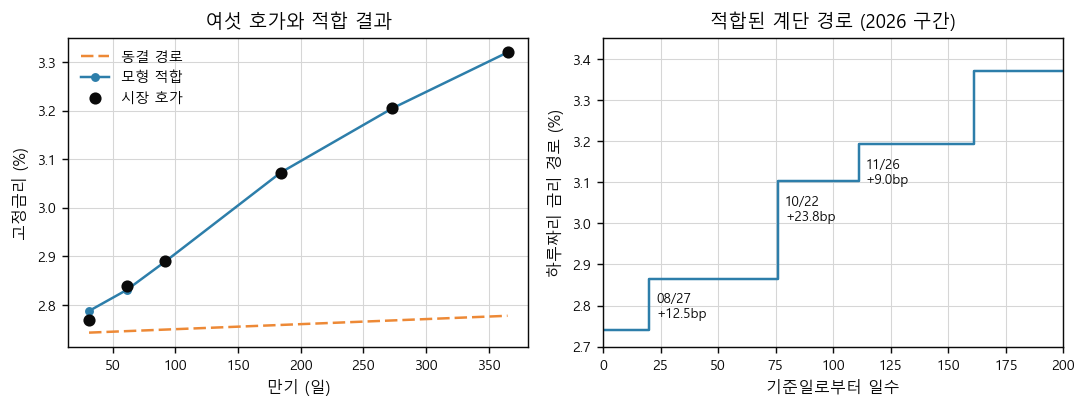

In [7]:
# 셀 (f) · 전체 워크스루 — 운영 모형 공표값과의 대조 포함
print("=" * 62)
print(f"기준일 {ASOF} · r0 = {r0:.3f}% (1주 호가) · 기준금리 {BASE_RATE}%")
print("=" * 62)
print("만기    시장호가   동결경로   초과분    모형적합   잔차")
for t, yf in zip(FIT_TENORS, fitted):
    d_ = DAYS[t]
    hold_t = model_rate(ASOF, d_, r0, ALL_NODES, np.zeros(len(ALL_NODES)))
    ym = QUOTES[t]
    print(f"{t:<6s} {ym:8.4f}  {hold_t:8.4f}  {(ym-hold_t)*100:+6.1f}bp"
          f"  {yf:8.4f}  {(ym-yf)*100:+5.1f}bp")

print("\n회의별 점프와 확률:")
cum = BASE_RATE
for n, d_, ph in zip(ALL_NODES, dl, IS_PH):
    cum += d_
    tag = "(2027 가정)" if ph else "          "
    print(f"  {n} {tag}  Δ = {d_*100:+6.2f}bp   P = {min(max(d_/0.25,0),1):5.1%}"
          f"   회의 후 내재 {cum:.3f}%")
ye = BASE_RATE + sum(d_ for n, d_, ph in zip(ALL_NODES, dl, IS_PH) if not ph)
print(f"\n연말 내재 기준금리 = {ye:.2f}%  (2026 점프 합 {sum(dl[:3])*100:+.1f}bp)")

# 운영 모형(m1_step_function.py, v7)의 공표값과 대조
REF = {"2026-08-27": 12.54, "2026-10-22": 23.77, "2026-11-26": 9.00}
ok = all(abs(dl[i] * 100 - REF[n.isoformat()]) < 0.05
         for i, n in enumerate(ALL_NODES[:3]))
print("운영 모형 v7 공표값(12.54/23.77/9.00bp)과 0.05bp 내 일치:", ok)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(8.6, 3.3))
xs = [DAYS[t] for t in FIT_TENORS]
hold_c = [model_rate(ASOF, d_, r0, ALL_NODES, np.zeros(len(ALL_NODES))) for d_ in xs]
axL.plot(xs, hold_c, color=ORANGE, ls=(0, (5, 2)), label="동결 경로")
axL.plot(xs, fitted, color=CADBLUE, marker="o", ms=4, label="모형 적합")
axL.scatter(xs, [QUOTES[t] for t in FIT_TENORS], s=34, color=INK, zorder=5,
            label="시장 호가")
axL.set_xlabel("만기 (일)"); axL.set_ylabel("고정금리 (%)")
axL.set_title("여섯 호가와 적합 결과"); axL.legend(loc="upper left")
days_grid = np.arange(0, 366)
path = np.full(len(days_grid), r0)
for n, d_ in zip(ALL_NODES, dl):
    b = (n - ASOF).days
    if b < len(days_grid):
        path[days_grid >= b] += d_ * 1
axR.step(days_grid, path, where="post", color=CADBLUE)
for n, d_ in zip(ALL_NODES[:3], dl[:3]):
    b = (n - ASOF).days
    axR.annotate(f"{n.strftime('%m/%d')}\n{d_*100:+.1f}bp",
                 xy=(b, r0 + np.sum(dl[:ALL_NODES.index(n) + 1])),
                 xytext=(4, -22), textcoords="offset points", fontsize=7.5,
                 color=INK)
axR.set_xlabel("기준일로부터 일수"); axR.set_ylabel("하루짜리 금리 경로 (%)")
axR.set_title("적합된 계단 경로 (2026 구간)")
axR.set_xlim(0, 200)
axR.set_ylim(2.70, 3.45)
save(fig, "10-fit-walkthrough.png")
plt.show()

**결과 읽기.** 왼쪽 표가 이 방법론의 최종 답안지입니다. 동결 경로 열(2.743→2.778)이 "아무 일도 없을 때"의 눈금이고, 시장 호가가 그 위로 얼마나 떠 있는지(+2.7 ~ +54.2bp)가 인상 기대의 원료이며, 적합 잔차(−1.8 ~ +0.9bp)가 모형이 소화하지 못한 나머지입니다. 회의별로는 8/27 +12.5bp(P 50%), 10/22 +23.8bp(P 95%), 11/26 +9.0bp(P 36%), 연말 내재 3.20%입니다. 마지막 줄의 `True`가 이 노트북의 존재 이유입니다 — 여기서 밑바닥부터 다시 만든 엔진이 운영 모형 v7의 공표값을 0.05bp 안에서 재현했습니다.

**읽는 규율.** 누적(연말 3.20%, 약 1.8회 인상)은 여섯 호가가 함께 떠받치는 튼튼한 숫자이고, 회의별 배분(50/95/36)은 셀 (d)의 증폭이 완전히 사라진 것이 아니라 λ로 눌러 놓은 것입니다. 그래서 배분은 점추정이 아니라 방향과 대략의 크기로 읽습니다 — 다음 셀에서 그 폭을 직접 잽니다.

## 셀 (g) — 확률의 신뢰 폭: 호가 잡음 몬테카를로

**이 셀이 하는 일.** 입력 호가 일곱 개(경로 시작점을 주는 1주 호가 포함) 각각에 ±1틱(0.25bp) 균등 잡음을 동시에 얹어 2,000번 다시 적합하고, 회의별 확률이 어느 폭 안에서 움직이는지를 봅니다. 호가는 어차피 반틱~1틱의 미세 구조 잡음(호가 스프레드 안 위치, 수급)을 품고 있으므로, 이 실험이 주는 폭이 "잡음 때문에 확률을 몇 %p 단위까지만 진지하게 읽어야 하는가"의 답입니다.

호가 ±1틱 잡음 하의 확률 분포 (2000회):
회의      중앙값    5%분위   95%분위   폭(90%)
8/27      50.2%    48.1%    52.2%     4.0%p
10/22     95.1%    87.2%   100.0%    12.8%p
11/26     35.9%    25.0%    47.3%    22.4%p


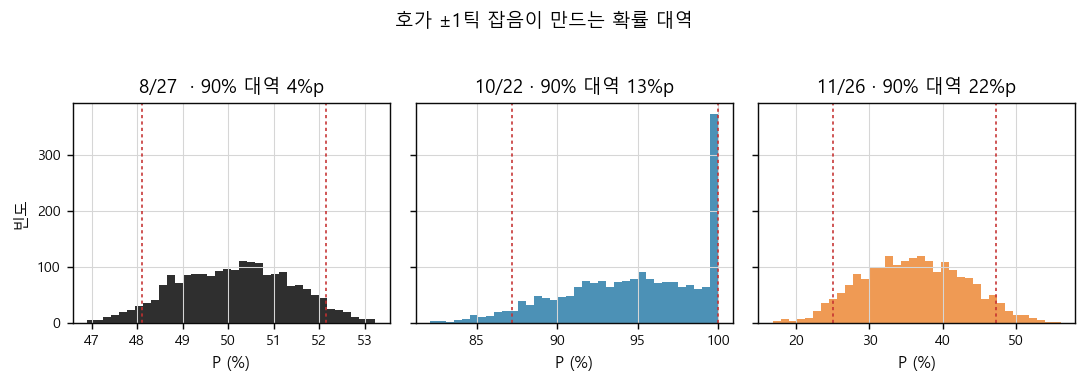

In [8]:
# 셀 (g) · 몬테카를로 — 호가 7개(1주 포함) ±1틱 균등 잡음, 2000회 재적합
rng = np.random.default_rng(20260807)
N = 2000
sims = np.zeros((N, 3))
for it in range(N):
    y2 = y + rng.uniform(-TICK, TICK, size=len(y))
    r0_2 = r0 + rng.uniform(-TICK, TICK)          # 경로 시작점(1주 호가)도 잡음
    d2, _, _, _ = fit_deltas(ASOF, days_l, y2, w, ALL_NODES, IS_PH, r0_2)
    sims[it] = [min(max(v / 0.25, 0), 1) for v in d2[:3]]

print("호가 ±1틱 잡음 하의 확률 분포 (2000회):")
print("회의      중앙값    5%분위   95%분위   폭(90%)")
labels = ["8/27 ", "10/22", "11/26"]
for j, lab in enumerate(labels):
    lo, md, hi = np.percentile(sims[:, j], [5, 50, 95]) * 100
    print(f"{lab}    {md:5.1f}%   {lo:5.1f}%   {hi:5.1f}%   {hi-lo:5.1f}%p")

fig, axes = plt.subplots(1, 3, figsize=(8.6, 2.9), sharey=True)
cols = [INK, CADBLUE, ORANGE]
for j, (ax, lab) in enumerate(zip(axes, labels)):
    ax.hist(sims[:, j] * 100, bins=36, color=cols[j], alpha=0.85)
    lo, hi = np.percentile(sims[:, j], [5, 95]) * 100
    ax.axvline(lo, color=CADRED, lw=0.9, ls=(0, (2, 2)))
    ax.axvline(hi, color=CADRED, lw=0.9, ls=(0, (2, 2)))
    ax.set_title(f"{lab} · 90% 대역 {hi-lo:.0f}%p")
    ax.set_xlabel("P (%)")
axes[0].set_ylabel("빈도")
fig.suptitle("호가 ±1틱 잡음이 만드는 확률 대역", y=1.02, fontsize=10.5)
save(fig, "11-noise-band-mc.png")
plt.show()

**결과 읽기.** 대역의 크기가 회의마다 극적으로 다릅니다 — 8월 ±2%p, 10월 ±6%p, 11월 ±11%p. 셀 (c)의 커버리지 구조가 그대로 재현된 것입니다. 8월은 그 회의만 보는 전용 호가가 둘(1·2개월)이나 있어 잡음이 들어와도 단단히 고정되고, 11월은 여러 만기가 이웃 회의와 섞어서만 보므로 잡음이 배분 사이를 휘젓고 다닙니다. "뒷 회의일수록 확률을 성기게 읽어라"가 감이 아니라 측정값으로 나옵니다.

**주의 — 이 대역이 불확실성의 전부가 아닙니다.** 여기서 잰 것은 **잡음**(호가의 통계적 흔들림)뿐입니다. 이와 별개로 **근사**(모형 가정이 만드는 한 방향 치우침)가 있습니다 — 연율화 관행을 잘못 고르면 8월이 20%p나 이동했고(셀 a), T+1 결제·영업일 조정을 반영하면 8월이 40%대 중반으로 내려간다는 외부 교차 검증도 있습니다. 잡음은 표본을 늘리면 줄지만 근사는 줄지 않으므로, 실무 보고서는 이 둘을 합쳐 8월을 "50%, 실무 범위 40~60%"의 대역으로 공표합니다 — 대역의 주범은 잡음이 아니라 근사 쪽입니다.

## 셀 (h) — 졸업시험: 2026-07-15 하루치를 처음부터 끝까지

**문제.** 아래는 7월 금통위(7/16) **전날**의 실제 데이터입니다. 이날 시장이 매긴 다음날 인상확률과 8월 인상확률을 구하세요.

| 입력 | 값 |
|---|---|
| KOFR OIS 호가 | 1주 2.775 · 1개월 2.770 · 2개월 2.830 · 3개월 2.880 · 6개월 3.005 · 9개월 3.165 · 1년 3.300 |
| 회의 노드 | **7/16** · 8/27 · 10/22 · 11/26 + 2027 가정(1/15 · 4/15 · 7/15) |
| 기준금리 | 2.50% (7/16 인상 전) |
| KOFR 7/15 공시값 | 2.546% |

**풀기 전에 반드시 짚을 함정 두 가지.**
1. 이날은 **1주 구간(7/15~7/22) 안에 회의가 있습니다.** 경로 시작점 r0를 1주 호가로 잡아도 되는지, 규칙이 무엇이었는지 떠올리세요(본문 §2.2).
2. 만기 일수와 회의까지 일수가 8/7과 전부 다릅니다. `tenor_days(date(2026,7,15), t)`로 다시 계산해야 합니다.

아래 빈 셀에 직접 푸세요. 그다음 셀이 정답입니다.

In [9]:
# (여기에 직접 풀어 보세요)


1주 구간 내 회의 여부: True => r0 = 2.546% (KOFR 폴백)
만기 일수: {'1개월': 31, '2개월': 62, '3개월': 92, '6개월': 184, '9개월': 274, '1년': 365}

적합 결과 (가중 RMSE 0.12bp):
  2026-07-16             Δ = +22.72bp   P = 90.9%
  2026-08-27             Δ = +18.34bp   P = 73.3%
  2026-10-22             Δ =  +6.20bp   P = 24.8%
  2026-11-26             Δ = +15.27bp   P = 61.1%
  2027-01-15 (2027 가정)  Δ = +25.44bp   P = 100.0%
  2027-04-15 (2027 가정)  Δ = +17.88bp   P = 71.5%
  2027-07-15 (2027 가정)  Δ = +11.92bp   P = 47.7%

답: 다음날(7/16) 인상확률 91% · 8/27 인상확률 73%
검증: 실제로 7/16 금통위는 25bp 인상(2.50 -> 2.75%)을 단행했다.


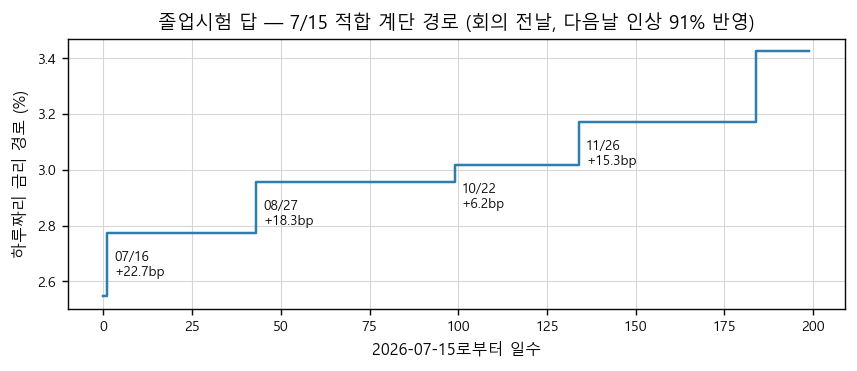

In [10]:
# 셀 (h) · 정답 — 7/15 하루치 전체 적합
EXAM_ASOF = date(2026, 7, 15)
EXAM_QUOTES = {"1주": 2.775, "1개월": 2.770, "2개월": 2.830, "3개월": 2.880,
               "6개월": 3.005, "9개월": 3.165, "1년": 3.300}
EXAM_NODES = [date(2026, 7, 16)] + MEETINGS_2026 + NODES_2027
EXAM_BASE, EXAM_KOFR = 2.50, 2.546

# 함정 1 — r0: 1주 구간(7/15~7/22)에 7/16 회의가 들어 있다.
# 1주 호가 2.775는 "회의 결과가 섞인 평균"이라 시작 수준이 될 수 없다.
# 규칙: 이때는 KOFR 최근 공시값으로 폴백한다.
meeting_in_week = any(EXAM_ASOF < m <= EXAM_ASOF + timedelta(days=7)
                      for m in EXAM_NODES)
exam_r0 = EXAM_KOFR if meeting_in_week else EXAM_QUOTES["1주"]
print(f"1주 구간 내 회의 여부: {meeting_in_week} => r0 = {exam_r0}% (KOFR 폴백)")

exam_days = [tenor_days(EXAM_ASOF, t) for t in FIT_TENORS]
exam_y = np.array([EXAM_QUOTES[t] for t in FIT_TENORS])
exam_ph = np.array([n.year == 2027 for n in EXAM_NODES])
print("만기 일수:", dict(zip(FIT_TENORS, exam_days)))

exam_dl, exam_rmse, exam_fit, _ = fit_deltas(
    EXAM_ASOF, exam_days, exam_y, w, EXAM_NODES, exam_ph, exam_r0)
print(f"\n적합 결과 (가중 RMSE {exam_rmse*100:.2f}bp):")
for n, d_, ph in zip(EXAM_NODES, exam_dl, exam_ph):
    tag = "(2027 가정)" if ph else "          "
    print(f"  {n} {tag}  Δ = {d_*100:+6.2f}bp   P = {min(max(d_/0.25,0),1):5.1%}")

p16 = min(max(exam_dl[0] / 0.25, 0), 1)
p_aug = min(max(exam_dl[1] / 0.25, 0), 1)
print(f"\n답: 다음날(7/16) 인상확률 {p16:.0%} · 8/27 인상확률 {p_aug:.0%}")
print("검증: 실제로 7/16 금통위는 25bp 인상(2.50 -> 2.75%)을 단행했다.")

fig, ax = plt.subplots(figsize=(6.8, 3.0))
days_grid = np.arange(0, 200)
path = np.full(len(days_grid), exam_r0)
for n, d_ in zip(EXAM_NODES, exam_dl):
    b = (n - EXAM_ASOF).days
    if b < len(days_grid):
        path[days_grid >= b] += d_
ax.step(days_grid, path, where="post", color=CADBLUE)
for n, d_ in zip(EXAM_NODES[:4], exam_dl[:4]):
    b = (n - EXAM_ASOF).days
    lvl = exam_r0 + sum(exam_dl[:EXAM_NODES.index(n) + 1])
    ax.annotate(f"{n.strftime('%m/%d')}\n{d_*100:+.1f}bp", xy=(b, lvl),
                xytext=(4, -24), textcoords="offset points", fontsize=7.5, color=INK)
ax.set_xlabel("2026-07-15로부터 일수"); ax.set_ylabel("하루짜리 금리 경로 (%)")
ax.set_title("졸업시험 답 — 7/15 적합 계단 경로 (회의 전날, 다음날 인상 91% 반영)")
save(fig, "13-exam-answer.png")
plt.show()

**해설.** 이 문제의 심장은 함정 1입니다. 1주 호가 2.775%는 회의 전 1일 + 회의 후 6일의 평균이므로 이미 인상 기대가 섞인 값입니다 — 이걸 r0로 쓰면 "인상 기대를 시작 수준에 넣어 놓고 다시 인상확률을 재는" 순환이 됩니다. 그래서 규칙이 "1주 구간에 회의가 있으면 KOFR 공시값으로 폴백"입니다. 폴백값 2.546%가 기준금리 2.50%보다 4.6bp 높은 것도 정보입니다 — 회의 전날 자금시장이 이미 살짝 위로 떠 있었습니다.

적합 결과는 7/16 +22.7bp(P 91%) — 시장은 다음날 인상을 9할로 확신했고, 실제로 인상됐습니다. 8/27은 +18.3bp(P 73%)로 8/7 시점의 50%보다 높습니다. 7월 인상 **전에는** 시장이 8월 연속 인상까지 꽤 높게 봤다가, 7월 인상이 실현된 뒤 8월 기대가 반반으로 내려온 것입니다 — 확률이 정보(회의 결과·발언)에 따라 계속 갱신되는 생물이라는 것을 같은 엔진, 다른 날짜의 두 산출이 보여 줍니다.

여기까지 왔다면 이 방법론의 전부 — 재료(셀 a), 한 회의 독해(셀 b), 식별 구조(셀 c·d), 실전 엔진(셀 e), 전체 산출(셀 f), 불확실성(셀 g) — 를 손으로 재현한 것입니다. 새 날짜의 호가가 오면 셀 (h)의 틀에 넣어 그날의 확률을 직접 뽑을 수 있습니다.